DEM 2D — Distinct/Discrete Element Method Simulation
=============================================================

Simulates N spherical particles under gravity using:
  - Linear Spring-Dashpot (LSD) contact model
  - Verlet (Euler-Cromer) time integration
  - Particle–Particle and Particle–Wall contact detection
  - Full post-processing: contact forces, kinetic/potential energy, packing

Formulation:
  Contact force (normal):   Fn = kn * δ  − cn * v_rel_n
  Contact force (tangential): Ft = kt * δt (simplified, no sliding)
  Motion law:               m * a = Fg + Fn + Ft  (Newton's 2nd Law)
  Integration (Euler-Cromer):
      v(t+dt) = v(t) + a(t) * dt
      x(t+dt) = x(t) + v(t+dt) * dt

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

In [3]:
# STEP 1: INITIALIZATION — PARAMETERS & INITIAL STATE

# Simulation parameters
num_particles = 25
dt            = 5e-4       # Time step (s) — keep small for stability
num_steps     = 3000       # Total simulation steps
radius        = 0.3        # Particle radius (m)
box_size      = 5.0        # Square box side length (m)

# Material / contact parameters
rho       = 2500.0         # Density (kg/m³)
kn        = 5e4            # Normal spring stiffness (N/m)
cn        = 50.0           # Normal damping coefficient (N·s/m)
kt        = 0.5 * kn       # Tangential stiffness
gravity   = np.array([0.0, -9.81])  # m/s²

# Derived
mass = rho * np.pi * radius**2  # 2D "mass" (disc approximation)

print(f"  Particles     : {num_particles}")
print(f"  Radius        : {radius} m")
print(f"  Mass/particle : {mass:.4f} kg")
print(f"  kn            : {kn:.1e} N/m")
print(f"  dt            : {dt} s")
print(f"  Steps         : {num_steps}  (T = {num_steps*dt:.3f} s)")

# --- Place particles in a grid (avoid initial overlaps) ---
np.random.seed(42)
spacing = 2.1 * radius
cols = int(box_size / spacing)

pos = []
for row in range(num_particles):
    r = row // cols
    c = row % cols
    x = spacing / 2 + c * spacing
    y = box_size - spacing / 2 - r * spacing  # Start near top
    pos.append([x + np.random.uniform(-0.01, 0.01),
                y + np.random.uniform(-0.01, 0.01)])
pos = np.array(pos[:num_particles])
vel = np.zeros_like(pos)
acc = np.zeros_like(pos)

print(f"\n  Initial particle positions set (grid-based, top of box)\n")

  Particles     : 25
  Radius        : 0.3 m
  Mass/particle : 706.8583 kg
  kn            : 5.0e+04 N/m
  dt            : 0.0005 s
  Steps         : 3000  (T = 1.500 s)

  Initial particle positions set (grid-based, top of box)



In [4]:
# STEP 2: FORCE CALCULATION FUNCTION
#   Computes all forces on each particle for a given state

def compute_forces(pos, vel, radius, mass, kn, cn, kt, gravity,
                   box_size):
    """
    Compute total forces on all particles.

    Includes:
      - Gravity
      - Particle–Particle contacts (spring-dashpot)
      - Wall contacts (bottom, left, right; top is open)
    """
    n = len(pos)
    forces = np.zeros_like(pos)

    # Body force: gravity
    forces[:, 1] += gravity[1] * mass

    # --- Particle–Particle Contacts ---
    for i in range(n):
        for j in range(i + 1, n):
            diff = pos[i] - pos[j]
            dist = np.linalg.norm(diff)
            min_dist = 2 * radius

            if dist < min_dist and dist > 1e-12:
                # Normal vector from j → i
                normal = diff / dist
                # Normal overlap (compression positive)
                delta_n = min_dist - dist

                # Relative velocity (normal component)
                rel_vel = vel[i] - vel[j]
                v_n     = np.dot(rel_vel, normal)

                # Spring-Dashpot normal force
                fn = kn * delta_n - cn * v_n
                fn = max(fn, 0)  # No tension between particles

                # Apply equal and opposite
                forces[i] +=  fn * normal
                forces[j] -= fn * normal

    # --- Wall Contacts ---
    # Bottom wall (y = 0)
    mask_bot = pos[:, 1] - radius < 0
    if np.any(mask_bot):
        delta_w          = radius - pos[mask_bot, 1]
        v_w              = vel[mask_bot, 1]
        fn_w             = kn * delta_w - cn * v_w
        forces[mask_bot, 1] += np.maximum(fn_w, 0)

    # Left wall (x = 0)
    mask_left = pos[:, 0] - radius < 0
    if np.any(mask_left):
        delta_w             = radius - pos[mask_left, 0]
        v_w                 = vel[mask_left, 0]
        fn_w                = kn * delta_w - cn * v_w
        forces[mask_left, 0] += np.maximum(fn_w, 0)

    # Right wall (x = box_size)
    mask_right = pos[:, 0] + radius > box_size
    if np.any(mask_right):
        delta_w              = pos[mask_right, 0] + radius - box_size
        v_w                  = -vel[mask_right, 0]
        fn_w                 = kn * delta_w - cn * v_w
        forces[mask_right, 0] -= np.maximum(fn_w, 0)

    return forces

In [5]:
# STEP 3: MAIN TIME-INTEGRATION LOOP (Euler-Cromer / Verlet)

# Storage for post-processing
KE_history = []      # Kinetic energy
PE_history = []      # Potential energy
t_history  = []
snap_pos   = {}      # Snapshots

snap_times = {0, num_steps//4, num_steps//2, 3*num_steps//4, num_steps-1}

for step in range(num_steps):
    # 1. Force computation
    forces = compute_forces(pos, vel, radius, mass, kn, cn, kt,
                            gravity, box_size)

    # 2. Acceleration (Newton's 2nd Law)
    acc = forces / mass

    # 3. Euler-Cromer integration
    vel += acc * dt
    pos += vel * dt

    # 4. Hard-boundary clamp (failsafe)
    pos[:, 0] = np.clip(pos[:, 0], radius, box_size - radius)
    pos[:, 1] = np.clip(pos[:, 1], radius, box_size * 2)  # open top

    # 5. Energy tracking
    KE = 0.5 * mass * np.sum(vel**2)
    PE = mass * abs(gravity[1]) * np.sum(pos[:, 1])
    KE_history.append(KE)
    PE_history.append(PE)
    t_history.append(step * dt)

    if step in snap_times:
        snap_pos[step] = pos.copy()
        speed = np.linalg.norm(vel, axis=1)
        print(f"  t = {step*dt:.4f} s | KE = {KE:.4f} J | "
              f"PE = {PE:.4f} J | max_speed = {speed.max():.4f} m/s")

print(f"\n  Simulation complete — {num_steps} steps done\n")

KE_arr = np.array(KE_history)
PE_arr = np.array(PE_history)
TE_arr = KE_arr + PE_arr

  t = 0.0000 s | KE = 0.2126 J | PE = 668020.4856 J | max_speed = 0.0049 m/s
  t = 0.3750 s | KE = 119894.7872 J | PE = 547966.4767 J | max_speed = 3.6837 m/s
  t = 0.7500 s | KE = 479153.6295 J | PE = 196285.7441 J | max_speed = 7.6566 m/s
  t = 1.1250 s | KE = 1298765.7895 J | PE = 52007.1029 J | max_speed = 20.2923 m/s
  t = 1.4995 s | KE = 2612917.9888 J | PE = 52007.1029 J | max_speed = 29.7814 m/s

  Simulation complete — 3000 steps done



In [6]:
# STEP 4: POST-PROCESSING — CONTACT ANALYSIS

# Count contacts in final state
n_contacts = 0
contact_pairs = []
for i in range(num_particles):
    for j in range(i + 1, num_particles):
        dist = np.linalg.norm(pos[i] - pos[j])
        if dist < 2 * radius:
            n_contacts += 1
            overlap = 2 * radius - dist
            contact_pairs.append((i, j, overlap))

# Coordination number (avg contacts per particle)
coord_num = 2 * n_contacts / num_particles
print(f"  Active contacts at final step : {n_contacts}")
print(f"  Coordination number           : {coord_num:.2f}")
print(f"  Final KE                      : {KE_arr[-1]:.6f} J")
print(f"  Max ΔTE (energy drift)        : {np.ptp(TE_arr):.4f} J")

  Active contacts at final step : 61
  Coordination number           : 4.88
  Final KE                      : 2612917.988770 J
  Max ΔTE (energy drift)        : 1997206.8934 J


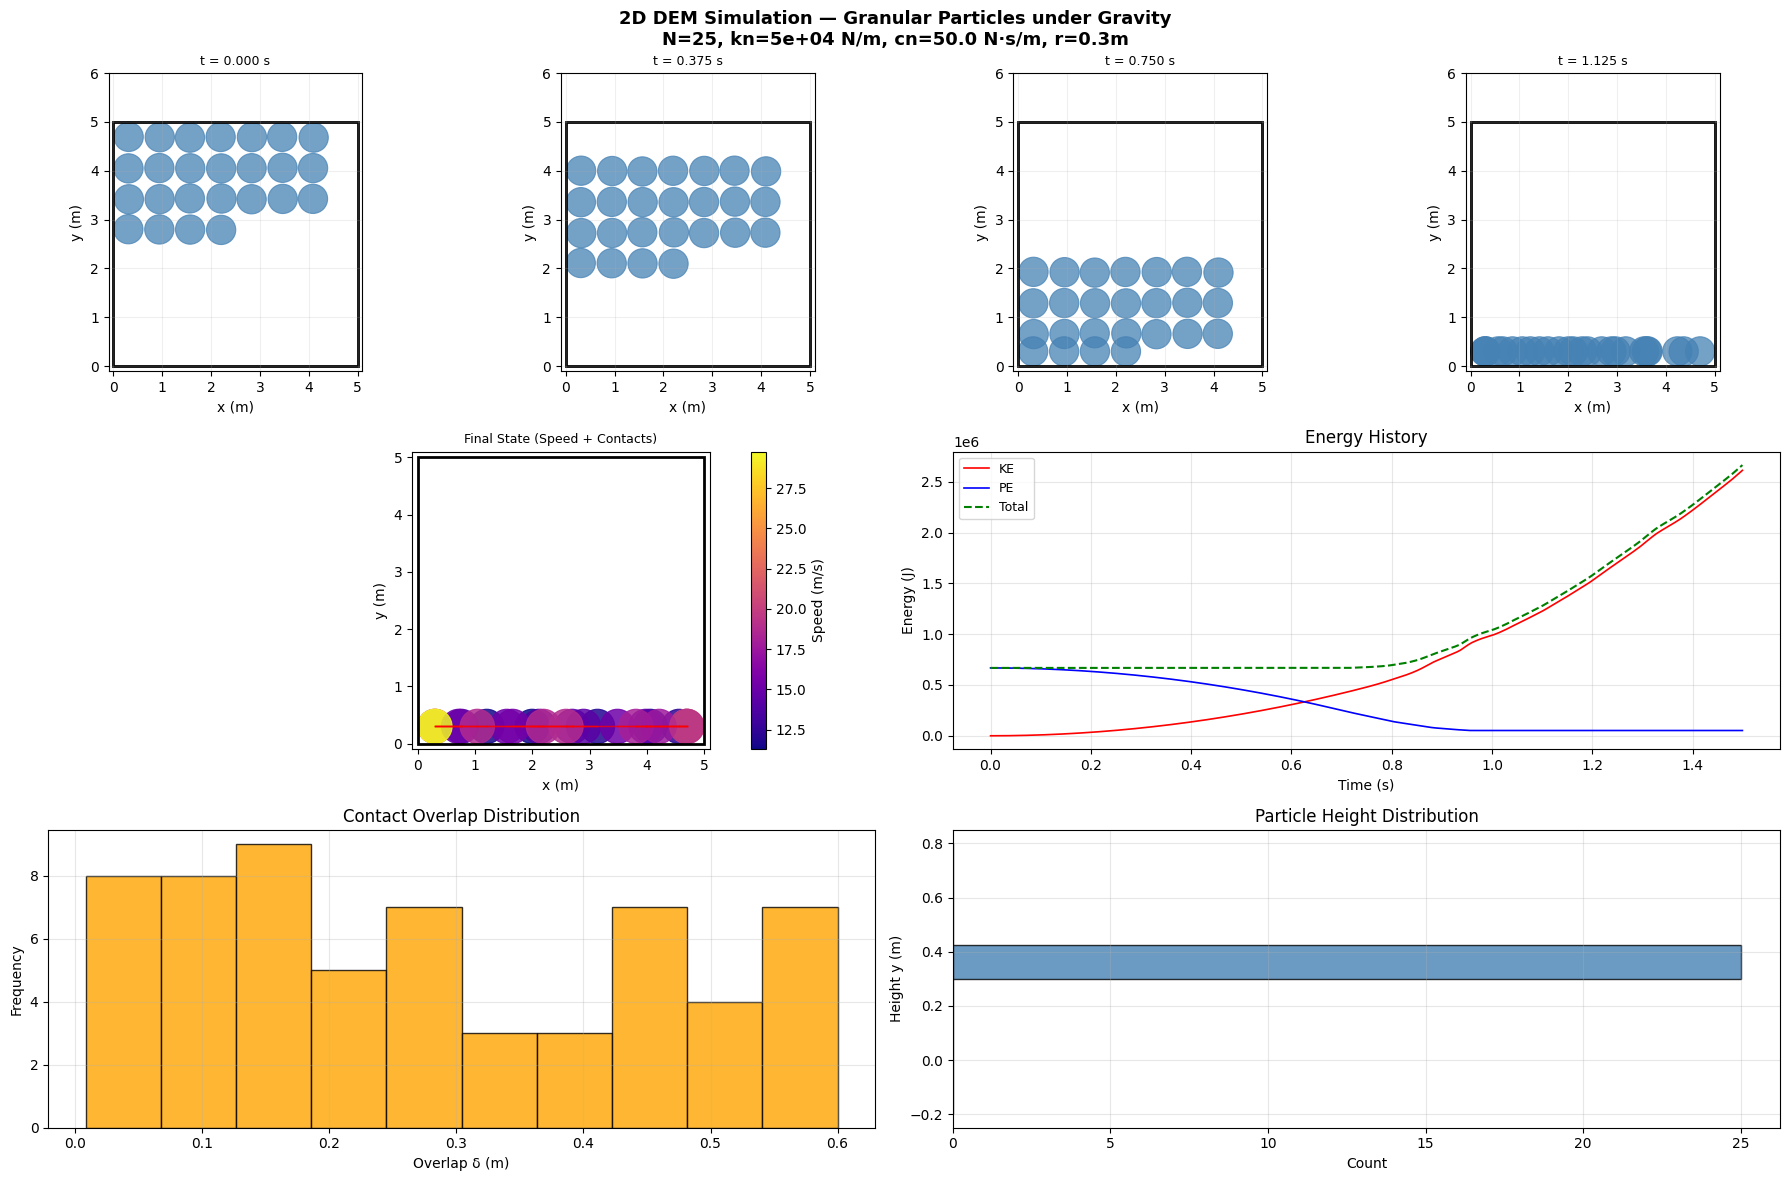

In [15]:
# STEP 5: VISUALIZATION

fig = plt.figure(figsize=(18, 12))
fig.suptitle("2D DEM Simulation — Granular Particles under Gravity\n"
             f"N={num_particles}, kn={kn:.0e} N/m, cn={cn} N·s/m, r={radius}m",
             fontsize=13, fontweight='bold')

# ---- 1. Snapshots ----
snap_list = sorted(snap_pos.keys())
for si, step_idx in enumerate(snap_list[:4]):
    ax = fig.add_subplot(3, 4, si + 1)
    p  = snap_pos[step_idx]
    speeds = np.zeros(num_particles)   # no velocity stored for snaps
    for idx in range(num_particles):
        circle = plt.Circle(p[idx], radius, color='steelblue',
                            alpha=0.75, linewidth=0.8, edgecolor='navy')
        ax.add_patch(circle)
    # Box walls
    rect = mpatches.FancyBboxPatch((0, 0), box_size, box_size,
                                    linewidth=2, edgecolor='black',
                                    facecolor='none', boxstyle='square,pad=0')
    ax.add_patch(rect)
    ax.set_xlim(-0.1, box_size + 0.1)
    ax.set_ylim(-0.1, box_size * 1.2)
    ax.set_aspect('equal')
    ax.set_title(f"t = {step_idx*dt:.3f} s", fontsize=9)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.grid(alpha=0.2)

# ---- 2. Final state with speed coloring ----
ax5 = fig.add_subplot(3, 4, (5, 6))
speeds_final = np.linalg.norm(vel, axis=1)
norm  = Normalize(vmin=speeds_final.min(), vmax=speeds_final.max() + 1e-10)
cmap  = plt.cm.plasma
for idx in range(num_particles):
    col    = cmap(norm(speeds_final[idx]))
    circle = plt.Circle(pos[idx], radius, color=col,
                        alpha=0.85, linewidth=0.8, edgecolor='black')
    ax5.add_patch(circle)
# Draw contact lines
for (i, j, ov) in contact_pairs:
    xvals = [pos[i][0], pos[j][0]]
    yvals = [pos[i][1], pos[j][1]]
    ax5.plot(xvals, yvals, 'r-', alpha=0.5, linewidth=1.0)
rect = mpatches.FancyBboxPatch((0, 0), box_size, box_size,
                                linewidth=2, edgecolor='black',
                                facecolor='none', boxstyle='square,pad=0')
ax5.add_patch(rect)
sm = ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=ax5, label='Speed (m/s)')
ax5.set_xlim(-0.1, box_size + 0.1)
ax5.set_ylim(-0.1, box_size + 0.1)
ax5.set_aspect('equal')
ax5.set_title("Final State (Speed + Contacts)", fontsize=9)
ax5.set_xlabel("x (m)"); ax5.set_ylabel("y (m)")

# ---- 3. Energy history ----
ax6 = fig.add_subplot(3, 4, (7, 8))
t_arr = np.array(t_history)
ax6.plot(t_arr, KE_arr, label='KE', color='red', linewidth=1.2)
ax6.plot(t_arr, PE_arr, label='PE', color='blue', linewidth=1.2)
ax6.plot(t_arr, TE_arr, label='Total', color='green', linewidth=1.5, linestyle='--')
ax6.set_xlabel("Time (s)")
ax6.set_ylabel("Energy (J)")
ax6.set_title("Energy History")
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

# ---- 4. Overlap / Contact force distribution ----
ax7 = fig.add_subplot(3, 4, (9, 10))
overlaps = [cp[2] for cp in contact_pairs]
if overlaps:
    ax7.hist(overlaps, bins=min(10, len(overlaps)), color='orange',
             edgecolor='black', alpha=0.8)
ax7.set_xlabel("Overlap δ (m)")
ax7.set_ylabel("Frequency")
ax7.set_title("Contact Overlap Distribution")
ax7.grid(alpha=0.3)

# ---- 5. Particle height distribution ----
ax8 = fig.add_subplot(3, 4, (11, 12))
ax8.hist(pos[:, 1], bins=8, color='steelblue', edgecolor='black', alpha=0.8,
         orientation='horizontal')
ax8.set_ylabel("Height y (m)")
ax8.set_xlabel("Count")
ax8.set_title("Particle Height Distribution")
ax8.grid(alpha=0.3)

plt.tight_layout()
plt.show()

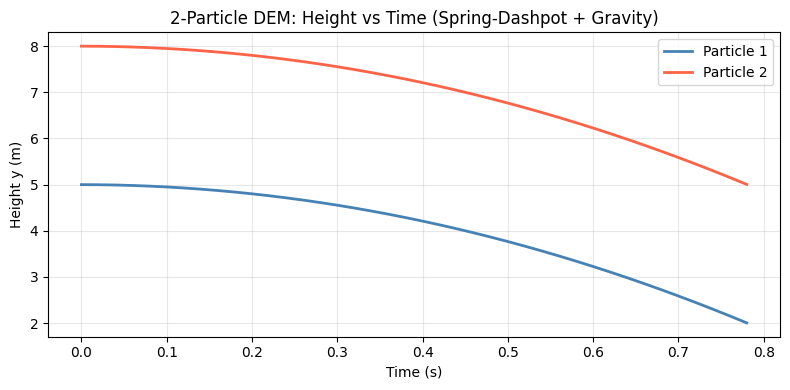

In [16]:
# LINEAR SPRING-DASHPOT TWO-PARTICLE DEMO

def simulate_dem_2particle(num_steps=800, dt=0.001):
    r = 0.5; m = 1.0
    kn = 2000.0; cn = 10.0
    g  = np.array([0, -9.81])

    # Two particles: one above the other
    pos2 = np.array([[0.0, 5.0], [0.4, 8.0]])
    vel2 = np.zeros_like(pos2)

    p1_y, p2_y, t_log = [], [], []

    for step in range(num_steps):
        forces = np.zeros_like(pos2)
        forces += m * g

        # Particle–Particle
        diff = pos2[0] - pos2[1]
        dist = np.linalg.norm(diff)
        overlap = 2 * r - dist
        if overlap > 0:
            normal  = diff / dist
            rel_vel = vel2[0] - vel2[1]
            f_mag   = kn * overlap - cn * np.dot(rel_vel, normal)
            f_vec   = f_mag * normal
            forces[0] += f_vec
            forces[1] -= f_vec

        # Ground wall
        for i in range(2):
            if pos2[i, 1] - r < 0:
                ov = r - pos2[i, 1]
                fgy = kn * ov - cn * vel2[i, 1]
                forces[i, 1] += max(fgy, 0)

        vel2 += (forces / m) * dt
        pos2 += vel2 * dt

        if step % 20 == 0:
            p1_y.append(pos2[0, 1])
            p2_y.append(pos2[1, 1])
            t_log.append(step * dt)

    return t_log, p1_y, p2_y

t_log, p1y, p2y = simulate_dem_2particle()

fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_log, p1y, label='Particle 1', color='steelblue', linewidth=2)
ax.plot(t_log, p2y, label='Particle 2', color='tomato', linewidth=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Height y (m)")
ax.set_title("2-Particle DEM: Height vs Time (Spring-Dashpot + Gravity)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()